
# Détection de fraude — pipeline Data Science complet, reproductible et sans data leakage

**Objectif :** construire un pipeline de classification binaire pour détecter les transactions frauduleuses, avec une démarche niveau entreprise : compréhension métier, EDA, prévention du data leakage, preprocessing sécurisé, gestion du déséquilibre, modélisation, optimisation, interprétabilité et simulation de mise en production.

**Contraintes respectées dans ce notebook :**
- split `train/test` **avant** toute transformation apprenante ;
- suppression des variables identifiantes à risque ;
- `Pipeline` / `ColumnTransformer` / `SMOTE` uniquement sur l'entraînement ;
- `RANDOM_STATE` fixé pour la reproductibilité ;
- évaluation finale réalisée **une seule fois sur le jeu de test**.



## 1. Compréhension du problème

Nous cherchons à résoudre un problème de **classification binaire supervisée** : prédire si une transaction est frauduleuse (`Fraudulent = 1`) ou non (`Fraudulent = 0`).

### Variable cible
- **Target :** `Fraudulent`

### Enjeux métier
En détection de fraude, le coût d'un **faux négatif** (ne pas détecter une fraude) est généralement supérieur au coût d'un faux positif (bloquer ou revoir une transaction légitime). En pratique, on donne donc une importance forte au **recall** de la classe fraude, tout en surveillant la **precision** pour éviter de trop dégrader l'expérience client et les coûts opérationnels.

### Type de machine learning
- **Apprentissage supervisé**
- **Classification binaire**


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

# ============================================================
# 2. Imports, configuration et chargement des données
# ============================================================

from pathlib import Path
import io
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance
%pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

candidate_paths = [
    Path('/content/drive/MyDrive/s6/Fraud Detection Dataset.csv'),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Le fichier 'Fraud Detection Dataset.csv' est introuvable. Placez-le dans le même dossier que le notebook ou adaptez DATA_PATH.")

ARTIFACT_DIR = DATA_PATH.parent / 'artifacts'
FIG_DIR = DATA_PATH.parent / 'figures'
ARTIFACT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print(f'Dataset utilisé : {DATA_PATH.resolve()}')


Dataset utilisé : /content/drive/MyDrive/s6/Fraud Detection Dataset.csv


In [3]:
# Chargement brut du dataset

df_raw = pd.read_csv(DATA_PATH)

print('Shape :', df_raw.shape)
display(df_raw.head())


Shape : (51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [4]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [5]:

df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,51000,50000,T49147,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_ID,51000.0,NaN,NaN,NaN,3005.110176,1153.121107,1000.0,2007.0,2996.0,4006.0,4999.0
Transaction_Amount,48480.0,NaN,NaN,NaN,2996.249784,5043.932555,5.03,1270.5525,2524.1,3787.24,49997.8
Transaction_Type,51000,5,Bill Payment,10340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_of_Transaction,48448.0,NaN,NaN,NaN,11.4884,6.922954,0.0,5.0,12.0,17.0,23.0
Device_Used,48527,4,Desktop,15795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,48453,8,Boston,6149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Previous_Fraudulent_Transactions,51000.0,NaN,NaN,NaN,1.995725,1.41515,0.0,1.0,2.0,3.0,4.0
Account_Age,51000.0,NaN,NaN,NaN,60.033902,34.384131,1.0,30.0,60.0,90.0,119.0
Number_of_Transactions_Last_24H,51000.0,NaN,NaN,NaN,7.495588,4.02008,1.0,4.0,7.0,11.0,14.0


In [6]:

# Contrôles de base : types, valeurs manquantes, doublons

missing_df = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_pct': (df_raw.isna().mean() * 100).round(2),
    'dtype': df_raw.dtypes.astype(str)
}).sort_values('missing_pct', ascending=False)

duplicates_count = df_raw.duplicated().sum()

print(f'Nombre de doublons exacts : {duplicates_count}')
missing_df


Nombre de doublons exacts : 881


,missing_count,missing_pct,dtype
Time_of_Transaction,2552,5.00,float64
Location,2547,4.99,object
Transaction_Amount,2520,4.94,float64
Device_Used,2473,4.85,object
Payment_Method,2469,4.84,object
Transaction_Type,0,0.00,object
Transaction_ID,0,0.00,object
User_ID,0,0.00,int64
Previous_Fraudulent_Transactions,0,0.00,int64
Account_Age,0,0.00,int64



## 3. EDA — analyse exploratoire

On réalise une exploration **visuelle** et **statistique** avant toute modélisation, afin de :
- comprendre les distributions ;
- quantifier le déséquilibre de classe ;
- détecter des signaux faibles, des valeurs atypiques et des incohérences ;
- préparer les hypothèses de feature engineering.


In [7]:

# Définition des colonnes

target_col = 'Fraudulent'
identifier_cols = ['Transaction_ID', 'User_ID']

numeric_cols_raw = df_raw.select_dtypes(include='number').columns.drop(target_col).tolist()
categorical_cols_raw = df_raw.select_dtypes(exclude='number').columns.tolist()

print('Variables numériques :', numeric_cols_raw)
print('Variables catégorielles :', categorical_cols_raw)


Variables numériques : ['User_ID', 'Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H']
Variables catégorielles : ['Transaction_ID', 'Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']


,count,pct
Fraudulent,,
0,48490,95.08
1,2510,4.92


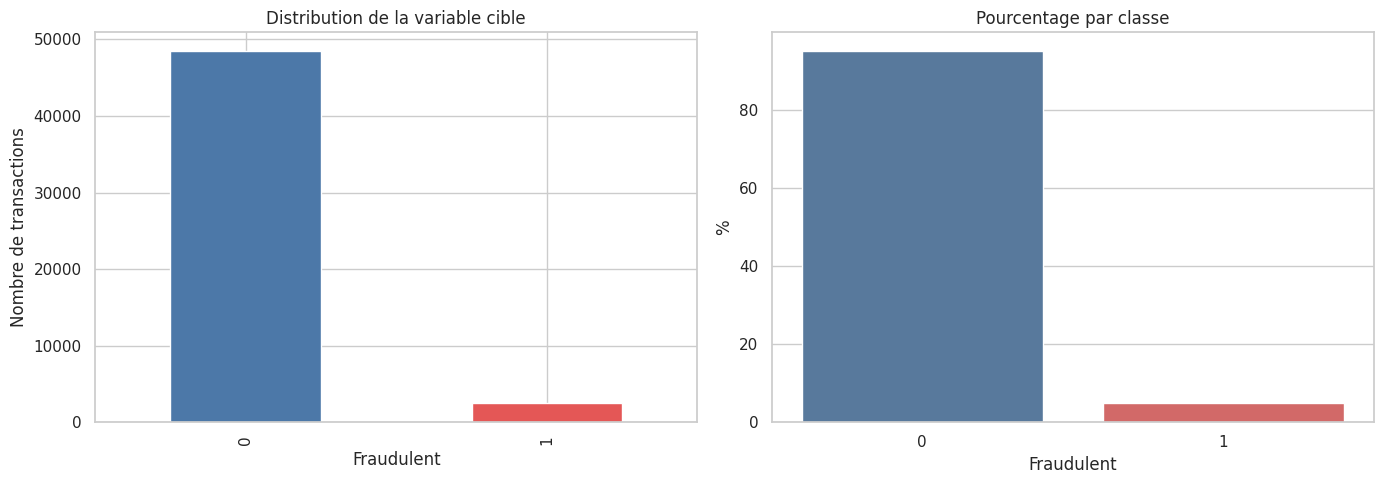

Ratio majorité / minorité : 19.32x


In [8]:

# Analyse de la target

target_distribution = df_raw[target_col].value_counts().sort_index()
target_pct = (df_raw[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

display(pd.DataFrame({'count': target_distribution, 'pct': target_pct}))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

target_distribution.plot(kind='bar', color=['#4C78A8', '#E45756'], ax=ax[0])
ax[0].set_title('Distribution de la variable cible')
ax[0].set_xlabel('Fraudulent')
ax[0].set_ylabel('Nombre de transactions')

sns.barplot(x=target_pct.index.astype(str), y=target_pct.values, palette=['#4C78A8', '#E45756'], ax=ax[1])
ax[1].set_title('Pourcentage par classe')
ax[1].set_xlabel('Fraudulent')
ax[1].set_ylabel('%')

plt.tight_layout()
plt.show()

imbalance_ratio = target_distribution.max() / target_distribution.min()
print(f'Ratio majorité / minorité : {imbalance_ratio:.2f}x')


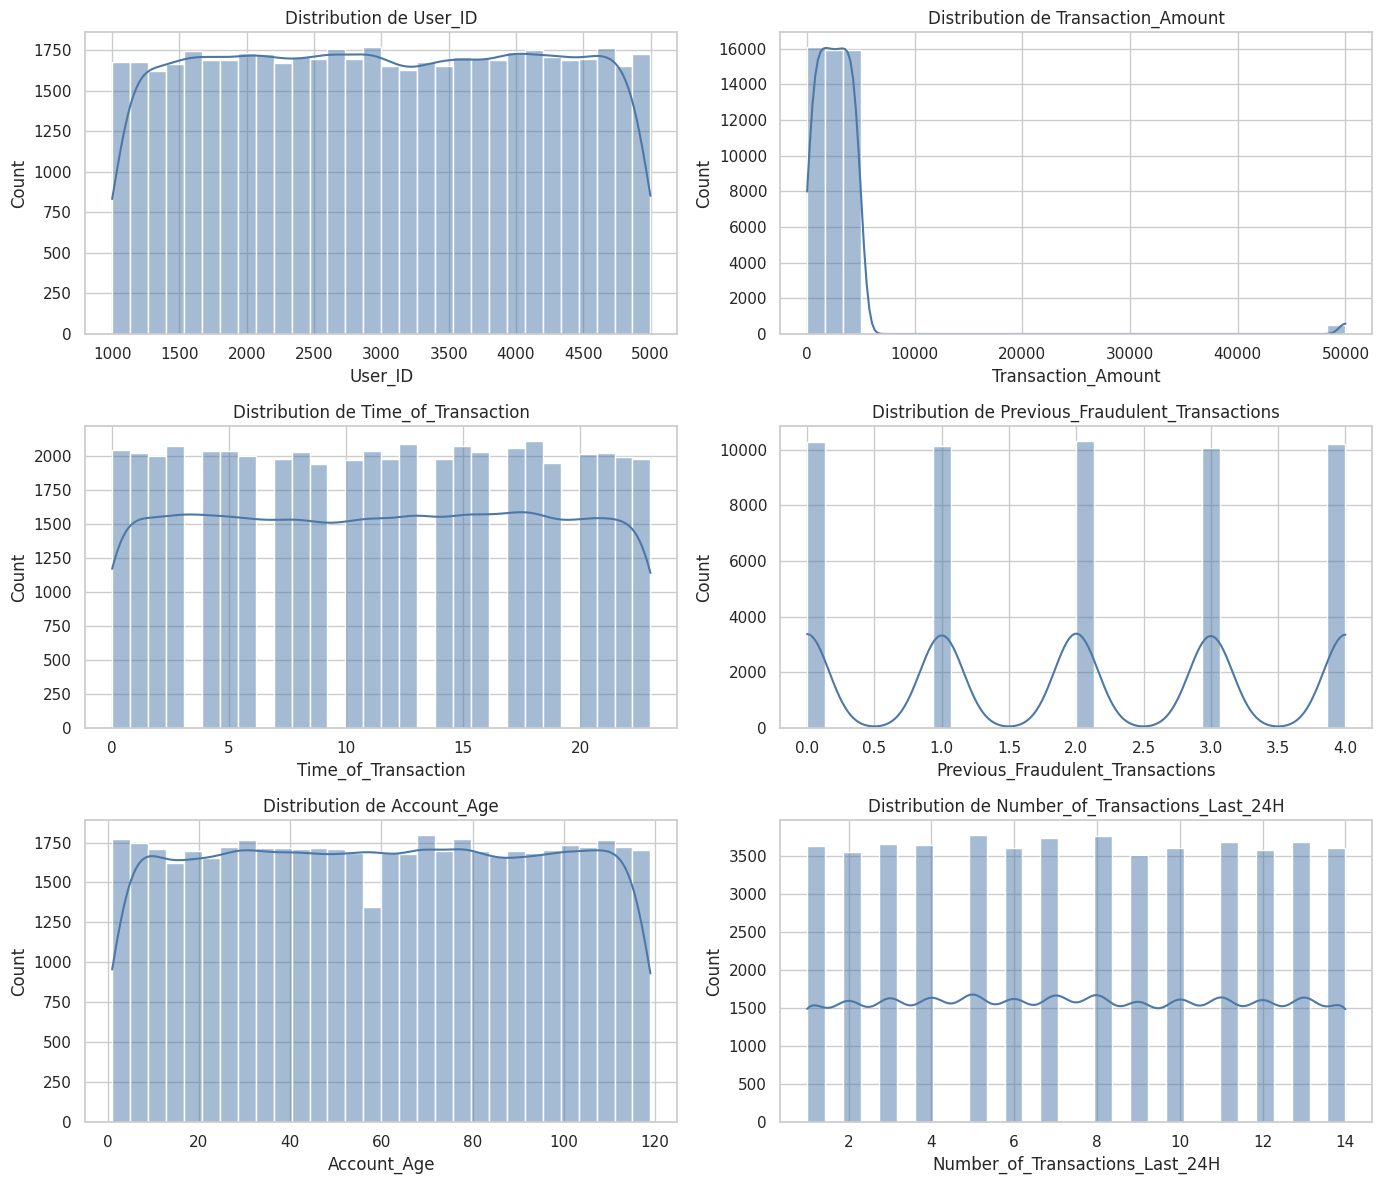

In [9]:

# Analyse univariée — variables numériques

n_num = len(numeric_cols_raw)
rows = int(np.ceil(n_num / 2))
fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols_raw):
    sns.histplot(df_raw[col], kde=True, bins=30, ax=ax, color='#4C78A8')
    ax.set_title(f'Distribution de {col}')

for ax in axes[n_num:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


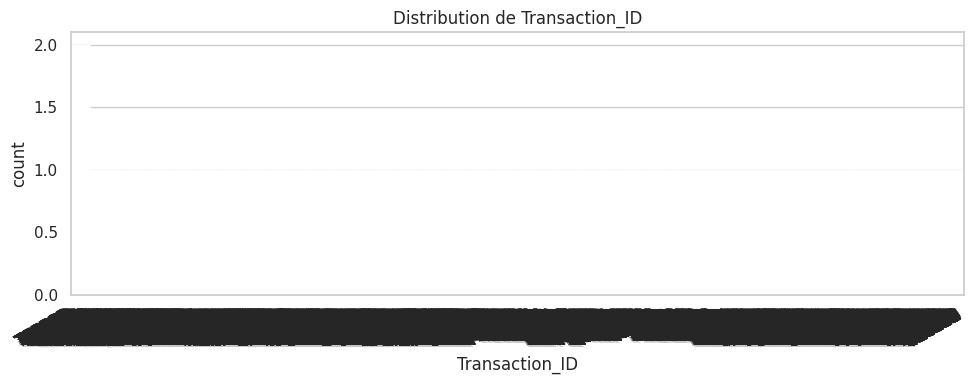

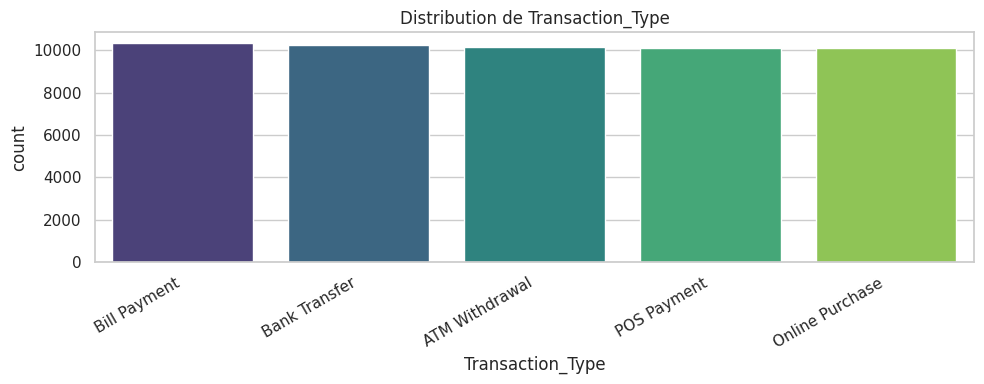

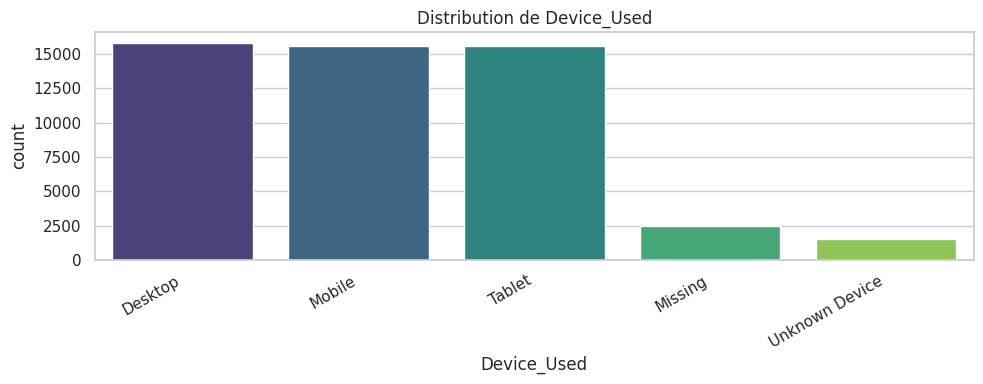

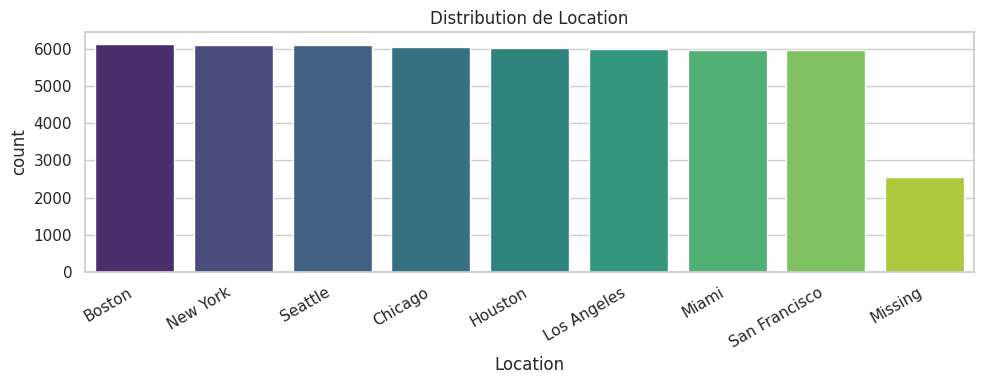

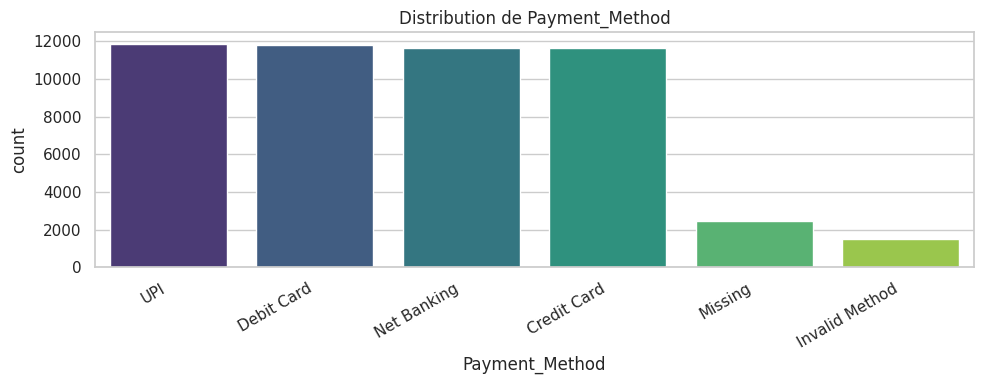

In [10]:

# Analyse univariée — variables catégorielles

for col in categorical_cols_raw:
    plt.figure(figsize=(10, 4))
    order = df_raw[col].fillna('Missing').value_counts().index
    sns.countplot(data=df_raw.assign(**{col: df_raw[col].fillna('Missing')}), x=col, order=order, palette='viridis')
    plt.title(f'Distribution de {col}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


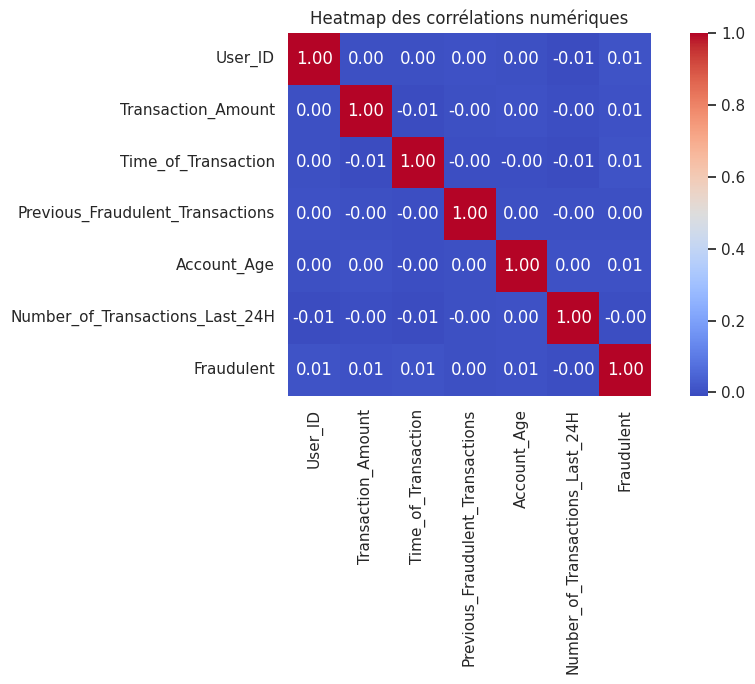

In [11]:

# Corrélations numériques

corr = df_raw.select_dtypes(include='number').corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Heatmap des corrélations numériques')
plt.tight_layout()
plt.show()


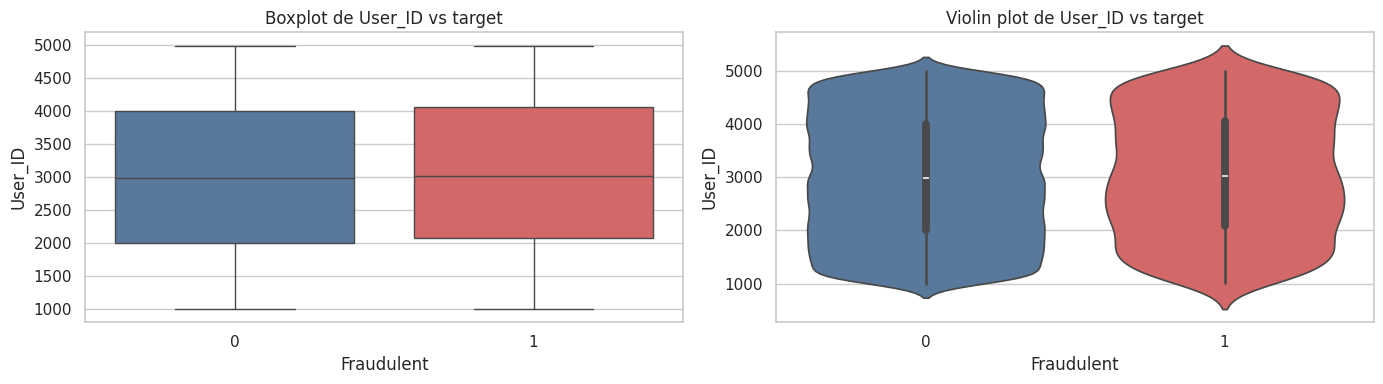

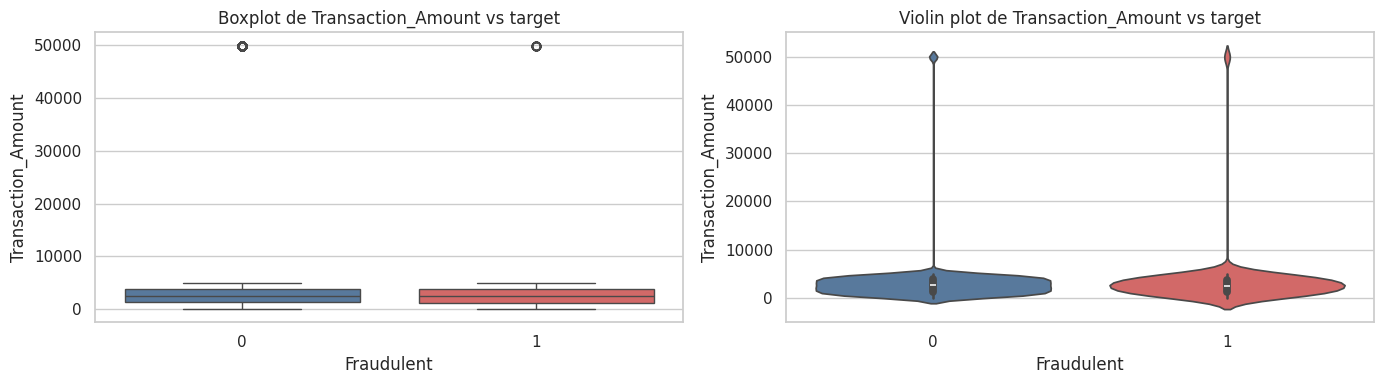

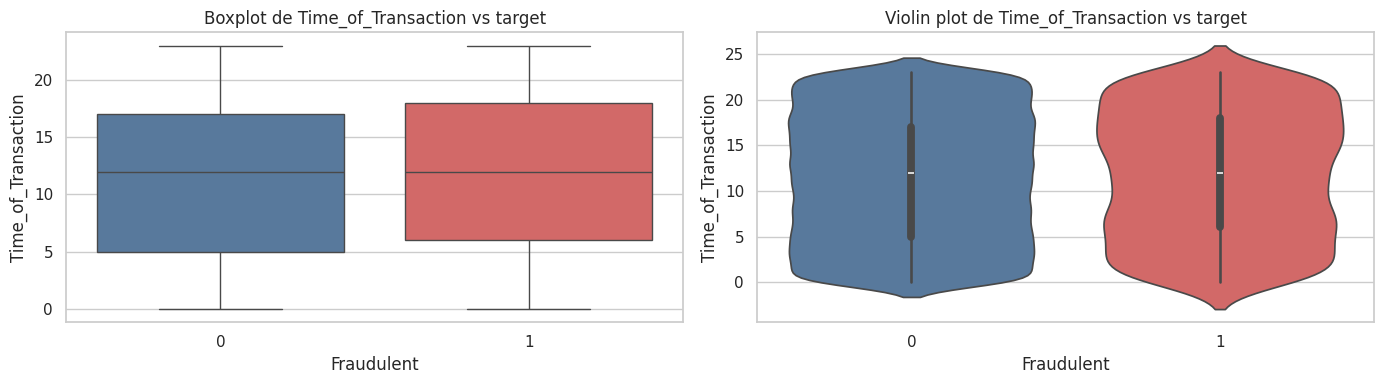

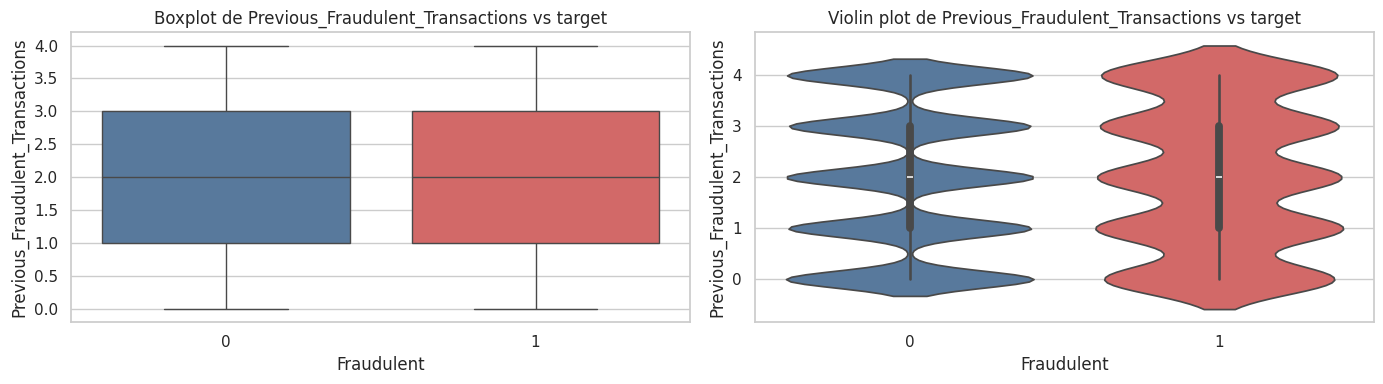

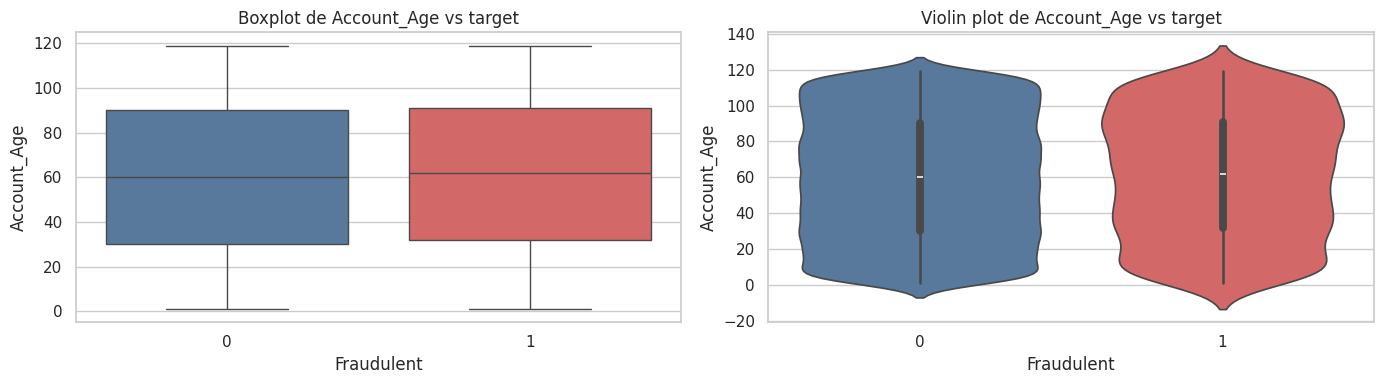

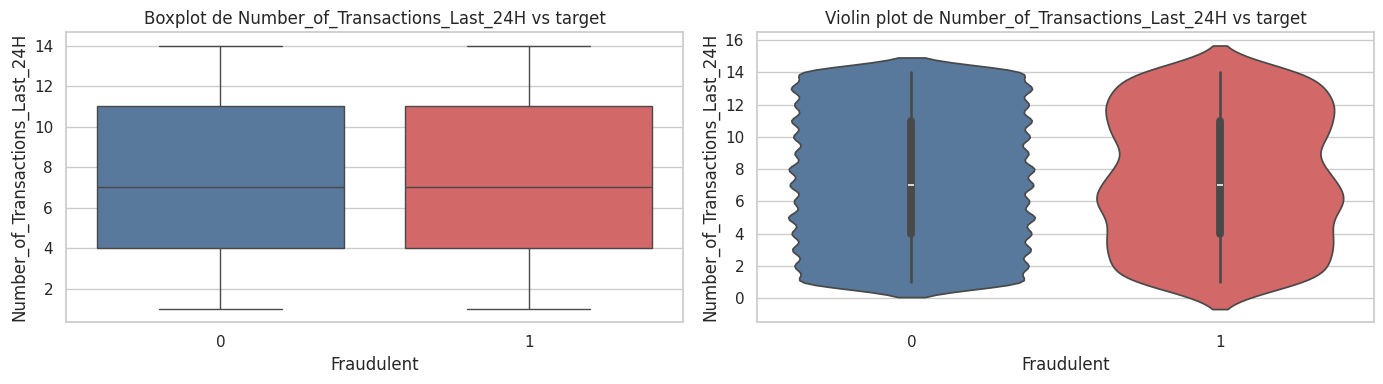

In [12]:

# Analyse bivariée : variables numériques vs target

for col in numeric_cols_raw:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.boxplot(data=df_raw, x=target_col, y=col, ax=axes[0], palette=['#4C78A8', '#E45756'])
    axes[0].set_title(f'Boxplot de {col} vs target')

    sns.violinplot(data=df_raw, x=target_col, y=col, ax=axes[1], palette=['#4C78A8', '#E45756'])
    axes[1].set_title(f'Violin plot de {col} vs target')
    plt.tight_layout()
    plt.show()


,count,mean,fraud_rate_pct
Transaction_ID,,,
T2379,1,1.0,100.0
T35023,1,1.0,100.0
T7820,1,1.0,100.0
T15136,1,1.0,100.0
T37480,1,1.0,100.0
...,...,...,...
T25379,1,0.0,0.0
T2538,1,0.0,0.0
T25380,1,0.0,0.0


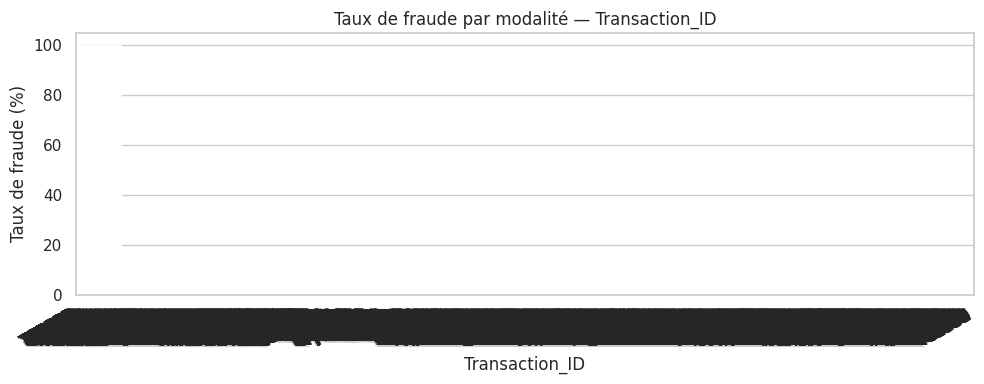

,count,mean,fraud_rate_pct
Transaction_Type,,,
Online Purchase,10094,0.051912,5.19
POS Payment,10126,0.050069,5.01
Bill Payment,10340,0.049516,4.95
Bank Transfer,10276,0.048073,4.81
ATM Withdrawal,10164,0.046537,4.65


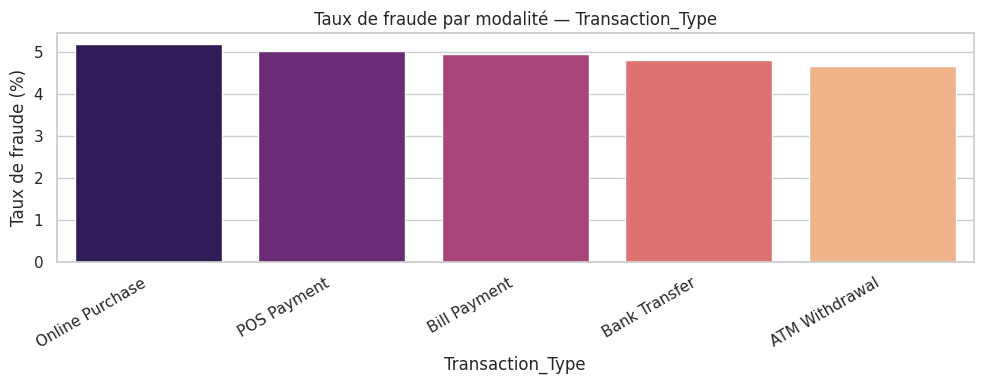

,count,mean,fraud_rate_pct
Device_Used,,,
Missing,2473,0.061464,6.15
Mobile,15614,0.051620,5.16
Unknown Device,1530,0.049020,4.90
Desktop,15795,0.047357,4.74
Tablet,15588,0.046767,4.68


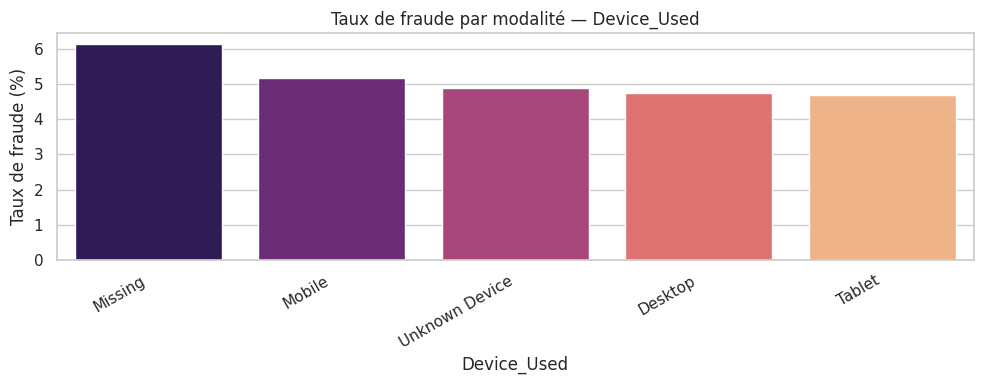

,count,mean,fraud_rate_pct
Location,,,
Chicago,6071,0.055016,5.50
Los Angeles,6012,0.051564,5.16
Boston,6149,0.050415,5.04
Miami,5991,0.049741,4.97
San Francisco,5985,0.049624,4.96
Missing,2547,0.048292,4.83
New York,6110,0.047463,4.75
Houston,6031,0.046758,4.68
Seattle,6104,0.043578,4.36


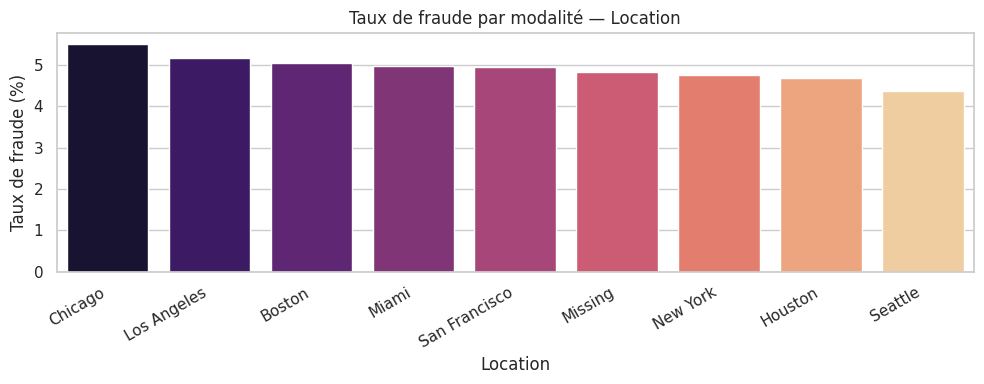

,count,mean,fraud_rate_pct
Payment_Method,,,
UPI,11887,0.051485,5.15
Credit Card,11646,0.049287,4.93
Net Banking,11666,0.049203,4.92
Debit Card,11802,0.048466,4.85
Invalid Method,1530,0.047712,4.77
Missing,2469,0.042527,4.25


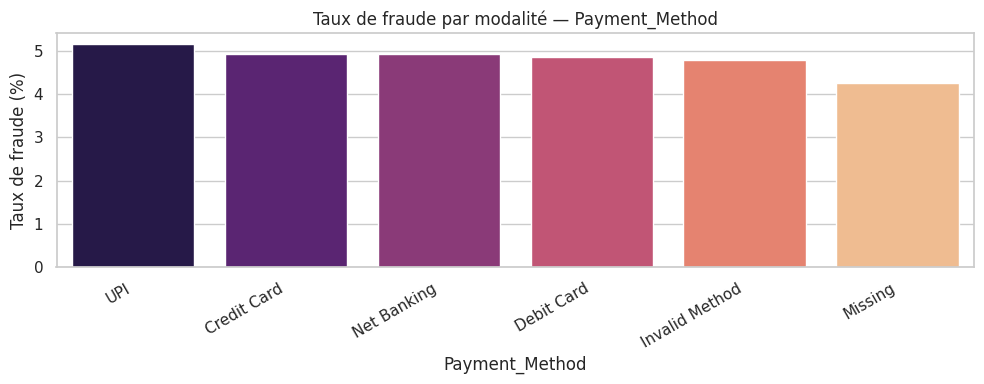

In [13]:

# Analyse bivariée : variables catégorielles vs target

for col in categorical_cols_raw:
    summary = (
        df_raw.assign(**{col: df_raw[col].fillna('Missing')})
             .groupby(col)[target_col]
             .agg(['count', 'mean'])
             .sort_values('mean', ascending=False)
    )
    summary['fraud_rate_pct'] = (summary['mean'] * 100).round(2)
    display(summary)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=summary.index, y=summary['fraud_rate_pct'], palette='magma')
    plt.title(f'Taux de fraude par modalité — {col}')
    plt.ylabel('Taux de fraude (%)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


In [14]:

# Détection simple des outliers via l'IQR

outlier_rows = []
for col in numeric_cols_raw:
    series = df_raw[col].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    pct_outliers = ((df_raw[col] < lower) | (df_raw[col] > upper)).mean() * 100
    outlier_rows.append({
        'feature': col,
        'q1': round(q1, 2),
        'q3': round(q3, 2),
        'iqr': round(iqr, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'pct_outliers': round(pct_outliers, 2),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('pct_outliers', ascending=False)
display(outlier_df)


,feature,q1,q3,iqr,lower_bound,upper_bound,pct_outliers
1,Transaction_Amount,1270.55,3787.24,2516.69,-2504.48,7562.27,1.0
0,User_ID,2007.00,4006.00,1999.00,-991.50,7004.50,0.0
2,Time_of_Transaction,5.00,17.00,12.00,-13.00,35.00,0.0
3,Previous_Fraudulent_Transactions,1.00,3.00,2.00,-2.00,6.00,0.0
4,Account_Age,30.00,90.00,60.00,-60.00,180.00,0.0
5,Number_of_Transactions_Last_24H,4.00,11.00,7.00,-6.50,21.50,0.0



## 4. Analyse du risque de data leakage

Le data leakage apparaît lorsqu'une information disponible au moment de l'entraînement ne serait pas réellement disponible au moment de la prédiction, ou lorsqu'une variable permet une mémorisation artificielle.

### Variables à risque ici
- **`Transaction_ID`** : identifiant unique transactionnel, non généralisable et potentiellement mémorisable.
- **`User_ID`** : identifiant client, potentiellement très cardinal et susceptible de faire apprendre des comportements spécifiques sans vraie capacité de généralisation.

Ces variables ne décrivent pas le phénomène métier sous-jacent ; elles peuvent dégrader la robustesse et créer un faux sentiment de performance. Elles seront donc **supprimées** avant la modélisation.

### Remarque méthodologique
Les doublons exacts seront retirés **avant le split** pour éviter qu'une même observation soit présente à la fois en entraînement et en test, ce qui gonflerait artificiellement les performances.


In [15]:

# Nettoyage minimal non apprenant : suppression des doublons exacts

df = df_raw.drop_duplicates().copy()
print(f'Shape après suppression des doublons : {df.shape}')

risk_table = pd.DataFrame({
    'variable': ['Transaction_ID', 'User_ID'],
    'niveau_risque': ['Élevé', 'Élevé'],
    'raison': [
        'Identifiant unique non causal, peut être mémorisé sans capacité de généralisation.',
        'Identifiant client à forte cardinalité, risque de mémorisation / surapprentissage.'
    ],
    'action': ['Supprimer', 'Supprimer']
})
display(risk_table)


Shape après suppression des doublons : (50119, 12)


,variable,niveau_risque,raison,action
0,Transaction_ID,Élevé,"Identifiant unique non causal, peut être mémor...",Supprimer
1,User_ID,Élevé,"Identifiant client à forte cardinalité, risque...",Supprimer



## 5. Preprocessing propre et sécurisé

Point méthodologique central : **le split train/test est effectué avant toute transformation apprenante**.

Ensuite, tout le preprocessing est encapsulé dans des pipelines :
- imputation des valeurs manquantes ;
- encodage OneHot des variables catégorielles ;
- standardisation des variables numériques ;
- application de `SMOTE` **uniquement sur le train** via un pipeline `imblearn`.


In [16]:

# Split train / test AVANT preprocessing

X = df.drop(columns=[target_col] + identifier_cols)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('X_train :', X_train.shape)
print('X_test  :', X_test.shape)
print('Taux de fraude train :', round(y_train.mean() * 100, 2), '%')
print('Taux de fraude test  :', round(y_test.mean() * 100, 2), '%')


X_train : (40095, 9)
X_test  : (10024, 9)
Taux de fraude train : 4.92 %
Taux de fraude test  : 4.92 %



## 6. Feature engineering

Le feature engineering doit lui aussi rester **dans le pipeline** pour éviter toute divergence entre entraînement et inférence.

Variables créées ici :
- `Is_Night` : transaction réalisée la nuit ;
- `Is_Business_Hours` : transaction pendant les heures ouvrées ;
- `Has_Previous_Fraud` : existence d'antécédents de fraude ;
- `Amount_per_24H_Transaction` : montant rapporté à l'intensité transactionnelle récente ;
- `Amount_to_Account_Age` : montant rapporté à l'ancienneté du compte.


In [17]:

class FraudFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if 'Time_of_Transaction' in X.columns:
            X['Is_Night'] = X['Time_of_Transaction'].apply(
                lambda x: np.nan if pd.isna(x) else int((x < 6) or (x >= 22))
            )
            X['Is_Business_Hours'] = X['Time_of_Transaction'].apply(
                lambda x: np.nan if pd.isna(x) else int(9 <= x <= 18)
            )

        if 'Previous_Fraudulent_Transactions' in X.columns:
            X['Has_Previous_Fraud'] = (X['Previous_Fraudulent_Transactions'] > 0).astype(int)

        if {'Transaction_Amount', 'Number_of_Transactions_Last_24H'}.issubset(X.columns):
            X['Amount_per_24H_Transaction'] = X['Transaction_Amount'] / (X['Number_of_Transactions_Last_24H'] + 1)

        if {'Transaction_Amount', 'Account_Age'}.issubset(X.columns):
            X['Amount_to_Account_Age'] = X['Transaction_Amount'] / (X['Account_Age'] + 1)

        return X

feature_engineer = FraudFeatureEngineer()
X_train_fe = feature_engineer.fit_transform(X_train)

numeric_cols = X_train_fe.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train_fe.select_dtypes(exclude='number').columns.tolist()

print('Colonnes numériques après feature engineering :')
print(numeric_cols)
print('Colonnes catégorielles après feature engineering :')
print(categorical_cols)


Colonnes numériques après feature engineering :
['Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Is_Night', 'Is_Business_Hours', 'Has_Previous_Fraud', 'Amount_per_24H_Transaction', 'Amount_to_Account_Age']
Colonnes catégorielles après feature engineering :
['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']


In [18]:

# Preprocessor sklearn obligatoire : ColumnTransformer + pipelines dédiés

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols),
])

print(preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Transaction_Amount', 'Time_of_Transaction',
                                  'Previous_Fraudulent_Transactions',
                                  'Account_Age',
                                  'Number_of_Transactions_Last_24H', 'Is_Night',
                                  'Is_Business_Hours', 'Has_Previous_Fraud',
                                  'Amount_per_24H_Transaction',
                                  'Amount_to_Account_Age']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder'


## 7. Gestion du déséquilibre

La classe fraude est minoritaire. Pour éviter qu'un modèle n'apprenne surtout à prédire la classe majoritaire, on utilise **SMOTE**.

 Important : `SMOTE` est appliqué **uniquement sur les folds d'entraînement** grâce au pipeline `imblearn`, jamais sur le test.


In [19]:

class_balance = pd.DataFrame({
    'count': y_train.value_counts().sort_index(),
    'pct': (y_train.value_counts(normalize=True).sort_index() * 100).round(2)
})
display(class_balance)


,count,pct
Fraudulent,,
0,38121,95.08
1,1974,4.92



## 8. Modélisation

Nous testons deux modèles principaux :
- **Logistic Regression** : baseline robuste, interprétable, rapide ;
- **Random Forest** : capte des relations non linéaires, interactions et hétérogénéité.
- **Decision Tree** : qui un type de model basé sur les arbres de decision

L'optimisation sera ensuite réalisée sur le meilleur candidat métier/validation.


In [22]:
from sklearn.tree import DecisionTreeClassifier

# Pipelines de modélisation compatibles cross-validation

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=250,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1,
        class_weight='balanced_subsample',
    ),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10, min_samples_split=5, min_samples_leaf=3),
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def make_pipeline(model):
    return ImbPipeline(steps=[
        ('feature_engineering', FraudFeatureEngineer()),
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model),
    ])

In [23]:

# Validation croisée sur le TRAIN uniquement
# Cette cellule peut prendre plusieurs minutes selon la machine.

cv_rows = []
fitted_baselines = {}

for model_name, model in models.items():
    pipeline = make_pipeline(model)
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1,  # plus sûr en environnement contraint
    )

    fitted_baselines[model_name] = pipeline.fit(X_train, y_train)

    row = {'model': model_name}
    for metric_name in scoring.keys():
        row[f'cv_train_{metric_name}_mean'] = scores[f'train_{metric_name}'].mean()
        row[f'cv_valid_{metric_name}_mean'] = scores[f'test_{metric_name}'].mean()
        row[f'cv_valid_{metric_name}_std'] = scores[f'test_{metric_name}'].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values(
    by=['cv_valid_pr_auc_mean', 'cv_valid_recall_mean'], ascending=False
).reset_index(drop=True)

display(cv_results.style.format(precision=4))


,model,cv_train_accuracy_mean,cv_valid_accuracy_mean,cv_valid_accuracy_std,cv_train_precision_mean,cv_valid_precision_mean,cv_valid_precision_std,cv_train_recall_mean,cv_valid_recall_mean,cv_valid_recall_std,cv_train_f1_mean,cv_valid_f1_mean,cv_valid_f1_std,cv_train_roc_auc_mean,cv_valid_roc_auc_mean,cv_valid_roc_auc_std,cv_train_pr_auc_mean,cv_valid_pr_auc_mean,cv_valid_pr_auc_std
0,RandomForest,1.0000,0.9501,0.0003,1.0000,0.1422,0.1491,1.0000,0.0025,0.0023,1.0000,0.0050,0.0045,1.0000,0.5025,0.0164,1.0000,0.0518,0.0041
1,LogisticRegression,0.5074,0.5035,0.0134,0.0540,0.0490,0.0006,0.5450,0.4939,0.0159,0.0982,0.0892,0.0011,0.5361,0.5006,0.0058,0.0552,0.0502,0.0014
2,DecisionTree,0.9457,0.9417,0.0048,0.2624,0.0558,0.0335,0.0485,0.0091,0.0057,0.0804,0.0154,0.0096,0.5865,0.4982,0.0144,0.0817,0.0499,0.0017


In [25]:

# Analyse train vs validation pour détecter surapprentissage / sous-apprentissage

gap_cols = []
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
    gap_cols.append({
        'metric': metric,
        'best_model': cv_results.loc[2, 'model'],
        'train_mean': cv_results.loc[2, f'cv_train_{metric}_mean'],
        'valid_mean': cv_results.loc[2, f'cv_valid_{metric}_mean'],
        'gap': cv_results.loc[0, f'cv_train_{metric}_mean'] - cv_results.loc[0, f'cv_valid_{metric}_mean'],
    })

generalization_df = pd.DataFrame(gap_cols)
display(generalization_df.style.format(precision=4))


,metric,best_model,train_mean,valid_mean,gap
0,accuracy,DecisionTree,0.9457,0.9417,0.0499
1,precision,DecisionTree,0.2624,0.0558,0.8578
2,recall,DecisionTree,0.0485,0.0091,0.9975
3,f1,DecisionTree,0.0804,0.0154,0.9950
4,roc_auc,DecisionTree,0.5865,0.4982,0.4975
5,pr_auc,DecisionTree,0.0817,0.0499,0.9482


In [26]:
dt_search_pipeline = make_pipeline(
    DecisionTreeClassifier(random_state=RANDOM_STATE)
)

param_distributions = {
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'smote__k_neighbors': [3, 5, 7],
}

random_search = RandomizedSearchCV(
    estimator=dt_search_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring='average_precision',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
)

random_search.fit(X_train, y_train)

print('Meilleurs hyperparamètres pour DecisionTree :')
print(random_search.best_params_)
print(f'Meilleur score CV (PR-AUC / average precision) : {random_search.best_score_:.4f}')

best_pipeline = random_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleurs hyperparamètres pour DecisionTree :
{'smote__k_neighbors': 3, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 15}
Meilleur score CV (PR-AUC / average precision) : 0.0517



## 10. Évaluation finale sur le TEST

 Le jeu de test n'est utilisé **qu'ici**, après sélection et tuning du modèle.


In [27]:

# Prédictions finales sur le test

y_test_pred = best_pipeline.predict(X_test)
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]

final_metrics = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc'],
    'value': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc_score(y_test, y_test_proba),
        average_precision_score(y_test, y_test_proba),
    ]
})

display(final_metrics.style.format({'value': '{:.4f}'}))
print(classification_report(y_test, y_test_pred, digits=4))


,metric,value
0,accuracy,0.5384
1,precision,0.0479
2,recall,0.4442
3,f1,0.0865
4,roc_auc,0.4930
5,pr_auc,0.0484


              precision    recall  f1-score   support

           0     0.9497    0.5433    0.6912      9531
           1     0.0479    0.4442    0.0865       493

    accuracy                         0.5384     10024
   macro avg     0.4988    0.4937    0.3888     10024
weighted avg     0.9054    0.5384    0.6614     10024



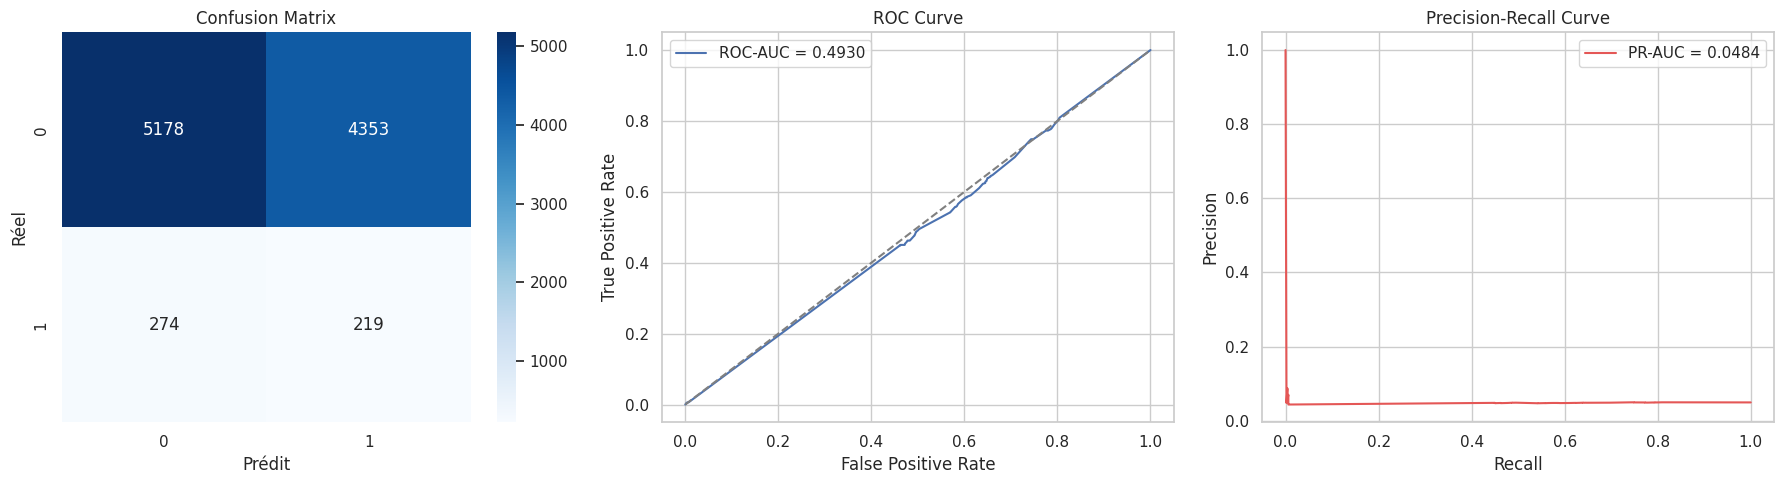

In [28]:

# Matrice de confusion, ROC Curve et Precision-Recall Curve

cm = confusion_matrix(y_test, y_test_pred)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_test_proba):.4f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
axes[2].plot(recall, precision, label=f'PR-AUC = {average_precision_score(y_test, y_test_proba):.4f}', color='#E45756')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()



## 11. Interprétation métier et analyse des résultats

Les points à commenter après exécution :
- **Recall fraude** : indicateur prioritaire si l'objectif est de capter un maximum de fraudes ;
- **Precision fraude** : coût opérationnel des alertes générées ;
- **PR-AUC** : métrique particulièrement adaptée au déséquilibre ;
- **écart train / validation** : diagnostic de surapprentissage ;
- **écart validation / test** : robustesse de généralisation.


In [29]:

# Commentaire automatique de premier niveau

metrics_dict = dict(zip(final_metrics['metric'], final_metrics['value']))

print('Résumé automatique :')
if metrics_dict['recall'] >= 0.70:
    print('- Le recall est élevé : le modèle capte une part importante des fraudes.')
elif metrics_dict['recall'] >= 0.50:
    print('- Le recall est intermédiaire : le modèle détecte une partie significative des fraudes, mais des améliorations restent possibles.')
else:
    print('- Le recall est faible : le modèle risque de laisser passer trop de fraudes.')

if metrics_dict['precision'] >= 0.50:
    print('- La precision est correcte : le volume de faux positifs reste relativement maîtrisé.')
else:
    print('- La precision est limitée : une partie notable des alertes concerne des transactions non frauduleuses.')

print(f"- ROC-AUC : {metrics_dict['roc_auc']:.4f}")
print(f"- PR-AUC  : {metrics_dict['pr_auc']:.4f}")


Résumé automatique :
- Le recall est faible : le modèle risque de laisser passer trop de fraudes.
- La precision est limitée : une partie notable des alertes concerne des transactions non frauduleuses.
- ROC-AUC : 0.4930
- PR-AUC  : 0.0484



## 12. Interprétabilité

Nous analysons :
- les **importances de variables** du RandomForest ;
- les **coefficients** d'une régression logistique entraînée sur le même pipeline.


,feature,importance
4,num__Number_of_Transactions_Last_24H,0.588428
26,cat__Location_Seattle,0.144342
14,cat__Transaction_Type_POS Payment,0.030475
1,num__Time_of_Transaction,0.028780
2,num__Previous_Fraudulent_Transactions,0.025806
17,cat__Device_Used_Tablet,0.020033
3,num__Account_Age,0.016207
30,cat__Payment_Method_Net Banking,0.013790
23,cat__Location_Miami,0.011911
8,num__Amount_per_24H_Transaction,0.011280


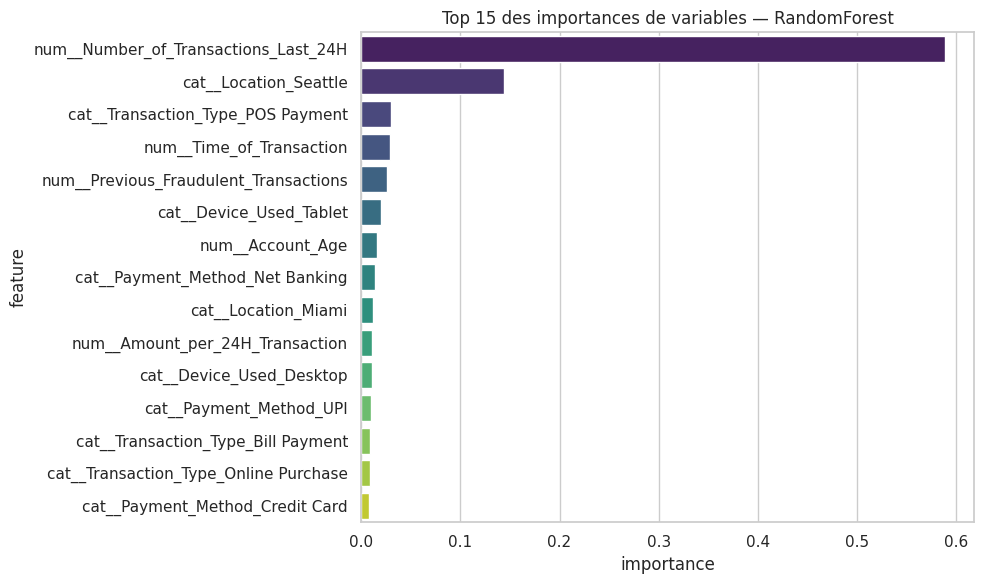

In [30]:

def get_feature_names_from_pipeline(fitted_pipeline):
    preprocessing = fitted_pipeline.named_steps['preprocessing']
    return preprocessing.get_feature_names_out()

feature_names = get_feature_names_from_pipeline(best_pipeline)
rf_model = best_pipeline.named_steps['model']

rf_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False)

display(rf_importances.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importances.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 des importances de variables — RandomForest')
plt.tight_layout()
plt.show()


,feature,coefficient
16,cat__Device_Used_Mobile,0.126703
20,cat__Location_Chicago,0.114018
30,cat__Payment_Method_Net Banking,0.094871
0,num__Transaction_Amount,0.084731
25,cat__Location_San Francisco,0.073295
15,cat__Device_Used_Desktop,0.053067
13,cat__Transaction_Type_Online Purchase,0.046625
1,num__Time_of_Transaction,0.046359
31,cat__Payment_Method_UPI,0.042457
3,num__Account_Age,0.042164


,feature,coefficient
5,num__Is_Night,0.008134
17,cat__Device_Used_Tablet,-0.001260
6,num__Is_Business_Hours,-0.008705
23,cat__Location_Miami,-0.019671
11,cat__Transaction_Type_Bank Transfer,-0.020329
9,num__Amount_to_Account_Age,-0.032667
24,cat__Location_New York,-0.033477
2,num__Previous_Fraudulent_Transactions,-0.034534
4,num__Number_of_Transactions_Last_24H,-0.046019
21,cat__Location_Houston,-0.068878


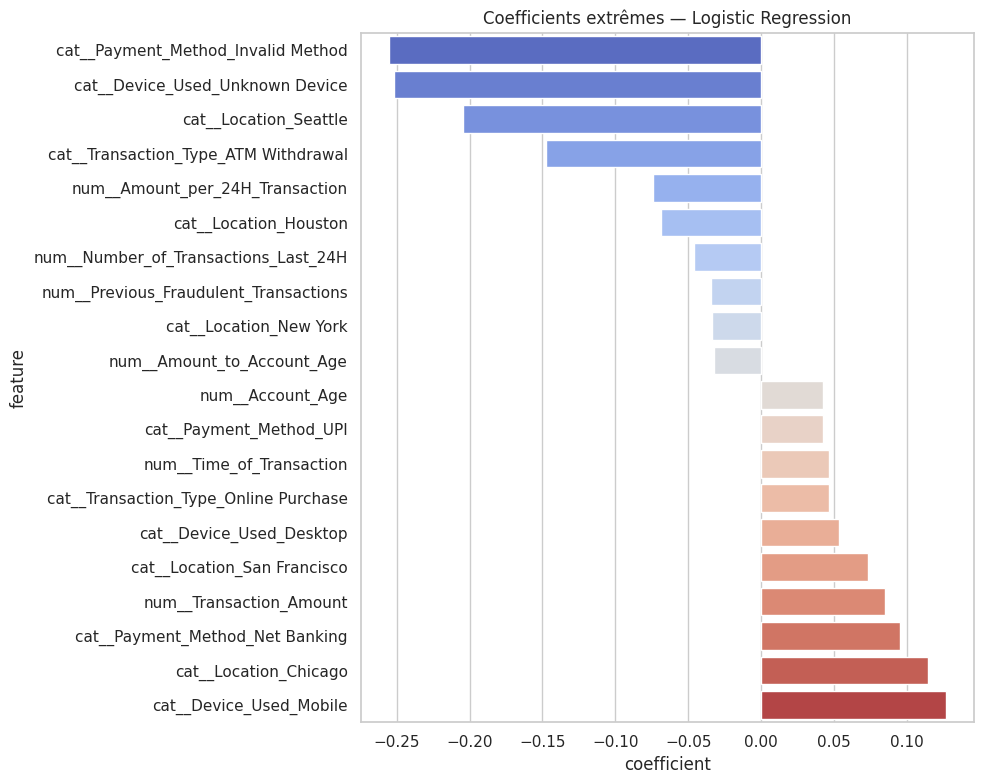

In [31]:

# Coefficients d'une Logistic Regression pour complément d'interprétabilité

logistic_interpret_pipeline = make_pipeline(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
)
logistic_interpret_pipeline.fit(X_train, y_train)

log_feature_names = get_feature_names_from_pipeline(logistic_interpret_pipeline)
log_model = logistic_interpret_pipeline.named_steps['model']

coef_df = pd.DataFrame({
    'feature': log_feature_names,
    'coefficient': log_model.coef_.ravel(),
}).sort_values('coefficient', ascending=False)

display(coef_df.head(15))
display(coef_df.tail(15))

plot_coef = pd.concat([coef_df.head(10), coef_df.tail(10)]).sort_values('coefficient')
plt.figure(figsize=(10, 8))
sns.barplot(data=plot_coef, x='coefficient', y='feature', palette='coolwarm')
plt.title('Coefficients extrêmes — Logistic Regression')
plt.tight_layout()
plt.show()


In [35]:
# Permutation importance (optionnel mais utile) sur le TEST pour le meilleur modèle

perm = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='average_precision',
)

perm_df = pd.DataFrame({
    'feature': X_test.columns, # Correction: Utiliser les noms des colonnes d'origine de X_test
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

display(perm_df.head(15))


,feature,importance_mean,importance_std
5,Previous_Fraudulent_Transactions,0.000218,0.000092
2,Time_of_Transaction,0.000151,0.000270
6,Account_Age,-0.000040,0.000294
8,Payment_Method,-0.000222,0.000663
3,Device_Used,-0.000289,0.000180
4,Location,-0.000340,0.000673
1,Transaction_Type,-0.000410,0.000548
0,Transaction_Amount,-0.000597,0.000534
7,Number_of_Transactions_Last_24H,-0.001532,0.000881



## 13. Robustesse et validation

La robustesse est vérifiée par :
- la validation croisée stratifiée ;
- la comparaison des scores **train vs validation** ;
- la mesure finale sur un **test hold-out** ;
- l'analyse du compromis recall / precision.

Si l'écart train-validation est fort, on suspecte un **overfitting**. Si les scores sont faibles partout, on suspecte plutôt un **underfitting** ou un manque de signal prédictif dans les variables disponibles.


In [36]:

# Lecture synthétique des gaps pour le meilleur modèle

best_model_name = cv_results.loc[2, 'model']
print('Meilleur modèle en CV :', best_model_name)
display(generalization_df.style.format(precision=4))


Meilleur modèle en CV : DecisionTree


,metric,best_model,train_mean,valid_mean,gap
0,accuracy,DecisionTree,0.9457,0.9417,0.0499
1,precision,DecisionTree,0.2624,0.0558,0.8578
2,recall,DecisionTree,0.0485,0.0091,0.9975
3,f1,DecisionTree,0.0804,0.0154,0.9950
4,roc_auc,DecisionTree,0.5865,0.4982,0.4975
5,pr_auc,DecisionTree,0.0817,0.0499,0.9482



## 14. Sauvegarde du modèle et simulation de mise en production

On sérialise le pipeline complet avec `joblib`. Cela inclut :
- feature engineering ;
- preprocessing ;
- SMOTE (utile pour la phase fit, neutre en inférence) ;
- modèle entraîné.

On simule ensuite des prédictions sur de nouvelles observations.


In [37]:

model_path = ARTIFACT_DIR / 'best_fraud_detection_pipeline.joblib'
joblib.dump(best_pipeline, model_path)
print(f'Modèle sauvegardé dans : {model_path}')


Modèle sauvegardé dans : /content/drive/MyDrive/s6/artifacts/best_fraud_detection_pipeline.joblib


In [38]:

# Simulation d'utilisation sur de nouvelles données

new_transactions = X_test.sample(5, random_state=RANDOM_STATE).copy()
new_predictions = best_pipeline.predict(new_transactions)
new_probabilities = best_pipeline.predict_proba(new_transactions)[:, 1]

inference_df = new_transactions.copy()
inference_df['predicted_label'] = new_predictions
inference_df['predicted_fraud_probability'] = new_probabilities.round(4)
display(inference_df)


,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,predicted_label,predicted_fraud_probability
38880,3658.94,Online Purchase,3.0,Mobile,Seattle,0,23,9,Credit Card,0,0.0000
14283,3844.28,Bank Transfer,19.0,Mobile,San Francisco,4,85,8,Net Banking,0,0.1968
15917,315.35,POS Payment,1.0,Tablet,Houston,1,90,6,UPI,1,0.5183
41416,4381.49,POS Payment,9.0,Mobile,Miami,1,9,5,Credit Card,1,0.5183
18044,2382.99,ATM Withdrawal,16.0,Desktop,Houston,1,112,2,UPI,1,0.5183



## 15. Conclusion métier

### Ce qu'il faut conclure après exécution
1. Le modèle est-il suffisamment bon pour être utilisé comme **filtre d'alerte** ?
2. Le recall est-il compatible avec le coût attendu des fraudes manquées ?
3. La precision est-elle compatible avec la capacité opérationnelle de revue manuelle ?
4. Le modèle généralise-t-il correctement hors entraînement ?

### Limites probables
- variables explicatives potentiellement peu informatives ;
- présence de valeurs manquantes non aléatoires ;
- absence d'historique séquentiel détaillé ;
- pas de coût métier explicite par erreur de classification ;
- pas de calibration de seuil avancée dans cette première version.

### Recommandations
- calibrer le **seuil de décision** selon le coût métier ;
- enrichir les données avec des signaux comportementaux/temps réel ;
- mettre en place un monitoring de drift ;
- suivre séparément recall fraude, precision fraude et taux d'alertes.



---
### Fin du notebook
Ce notebook constitue une base **propre, sécurisée et reproductible** pour un cas de détection de fraude tabulaire, avec un focus explicite sur la prévention du **data leakage**.
